In [13]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
import joblib, os, json, warnings
import sys
sys.path.append(r"D:\baitaplon\hr-churn-predictor\hr-churn-predictor\backend")
from custom_transformers.xgboost_transformers import XGB_MissingValueHandler, XGB_OrdinalMapper, XGB_FrequencyEncoder

In [14]:
file_id = '1e8ImAsI7nDfDyyDCRo6cy2Bde1WEa_mY' # ID file dataset
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df_raw = pd.read_csv(url)

In [15]:
# SECTION 3: PREPROCESSING PIPELINE
# ================================================================
# Loại bỏ enrollee_id — chỉ là định danh, không có giá trị dự đoán
df = df_raw.drop(columns=['enrollee_id'])

# Tách feature matrix X và vector nhãn y
X = df.drop(columns=['target'])
y = df['target'].astype(int)  # Chuyển sang int (0/1)

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Cột trong X: {list(X.columns)}')

# Train/Test Split 80/20 với stratify
RANDOM_STATE = 42
TEST_SIZE    = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y   # ← đảm bảo tỷ lệ nhãn nhất quán
)

print('✅ Phân chia tập dữ liệu:')
print(f'   Train set : {X_train.shape[0]:,} mẫu  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test set  : {X_test.shape[0]:,} mẫu   ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Kiểm tra tỷ lệ nhãn sau stratify:')
print(f'   y_train: {dict(y_train.value_counts(normalize=True).round(3))}')
print(f'   y_test : {dict(y_test.value_counts(normalize=True).round(3))}')
print()
print('🔒 Test set đã đóng băng — KHÔNG dùng trong bất kỳ bước tiền xử lý nào!')

X shape: (19158, 12)  |  y shape: (19158,)
Cột trong X: ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']
✅ Phân chia tập dữ liệu:
   Train set : 15,326 mẫu  (80%)
   Test set  : 3,832 mẫu   (20%)

Kiểm tra tỷ lệ nhãn sau stratify:
   y_train: {0: np.float64(0.751), 1: np.float64(0.249)}
   y_test : {0: np.float64(0.751), 1: np.float64(0.249)}

🔒 Test set đã đóng băng — KHÔNG dùng trong bất kỳ bước tiền xử lý nào!


### Khám phá các giá trị duy nhất của thuộc tính phân loại


### Kiểm chứng phân phối giữa tập Train và Test
Chúng ta sẽ so sánh nhãn mục tiêu và các đặc trưng như `city_development_index` (số) và `education_level` (hạng mục) để xem tập Test có đại diện tốt cho tổng thể không.

### So sánh phân phối cho toàn bộ các thuộc tính (Features)
Biểu đồ dưới đây so sánh tỷ lệ (%) của từng giá trị trong tập Train và Test đối với mọi cột dữ liệu.

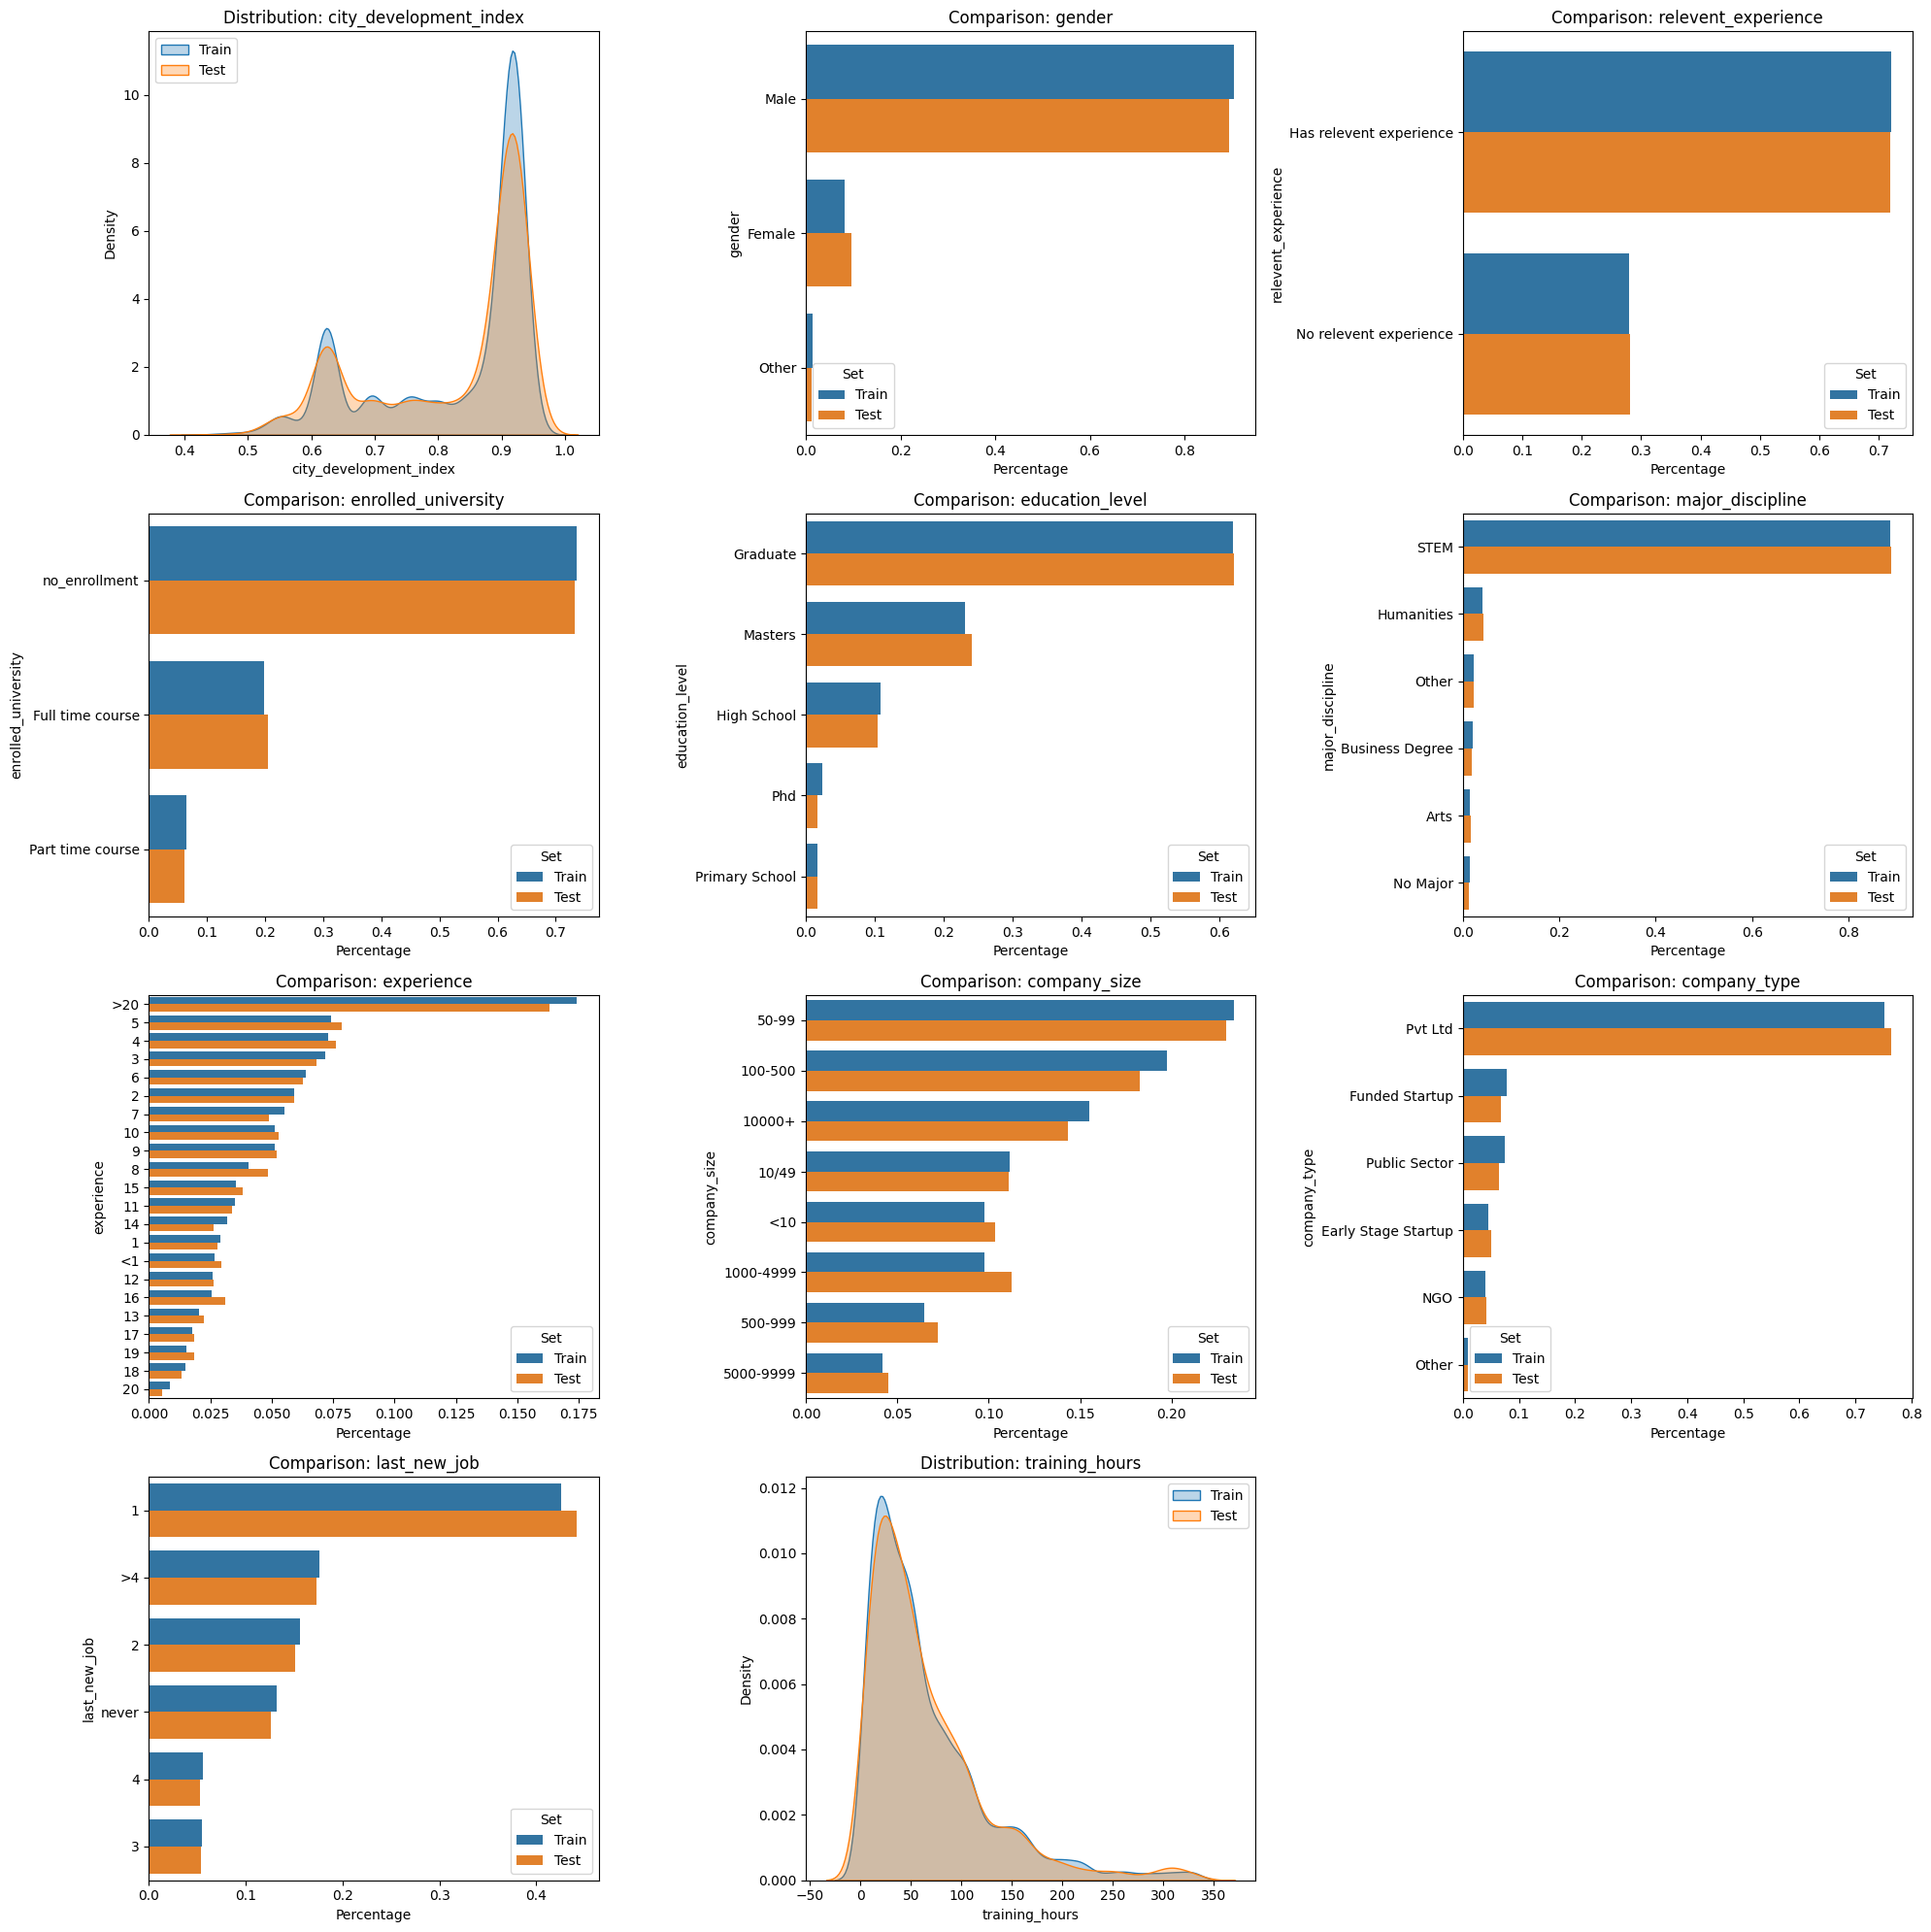

In [16]:
cols = [c for c in X_train.columns if c != 'city']
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    if X_train[col].dtype in ['float64', 'int64']:
        # Đối với dữ liệu số: dùng KDE plot
        sns.kdeplot(X_train[col], ax=axes[i], label='Train', fill=True, alpha=0.3)
        sns.kdeplot(X_test[col], ax=axes[i], label='Test', fill=True, alpha=0.3)
        axes[i].set_title(f'Distribution: {col}')
        axes[i].legend()
    else:
        # Đối với dữ liệu hạng mục: dùng Bar plot tỷ lệ %
        train_val = X_train[col].value_counts(normalize=True).rename('percentage').reset_index()
        train_val['Set'] = 'Train'
        test_val = X_test[col].value_counts(normalize=True).rename('percentage').reset_index()
        test_val['Set'] = 'Test'
        combined = pd.concat([train_val, test_val])

        sns.barplot(data=combined, y=col, x='percentage', hue='Set', ax=axes[i])
        axes[i].set_title(f'Comparison: {col}')
        axes[i].set_xlabel('Percentage')

# Ẩn các ô trống nếu số lượng cột không chia hết cho 3
for j in range(len(cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
# import numpy as np


# # ══════════════════════════════════════════════════════════════════════
# # BƯỚC 1 — Xử lý giá trị khuyết
# # ══════════════════════════════════════════════════════════════════════
# class MissingValueHandler(BaseEstimator, TransformerMixin):
#     # Nhóm 1: missing có ý nghĩa → category 'Unknown'
#     UNKNOWN_COLS = ['company_size', 'company_type', 'gender']

#     # Nhóm 2: không có chuyên ngành ≠ không khai báo → 'No Info'
#     NO_INFO_COLS = ['major_discipline']

#     # Nhóm 3: missing ngẫu nhiên, tỷ lệ thấp → mode
#     MODE_COLS = [
#         'relevent_experience',
#         'enrolled_university',
#         'education_level',
#         'experience',
#         'last_new_job',
#     ]

#     # Nhóm 4: biến liên tục có outlier → median
#     MEDIAN_COLS = ['city_development_index', 'training_hours']

#     def fit(self, X, y=None):
#         # Học mode và median CHỈ trên phần Train của mỗi fold
#         self.modes_   = {
#             col: X[col].mode()[0]
#             for col in self.MODE_COLS if col in X.columns
#         }
#         self.medians_ = {
#             col: X[col].median()
#             for col in self.MEDIAN_COLS if col in X.columns
#         }
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col in self.UNKNOWN_COLS:
#             if col in X.columns:
#                 X[col] = X[col].fillna('Unknown')
#         for col in self.NO_INFO_COLS:
#             if col in X.columns:
#                 X[col] = X[col].fillna('No Info')
#         for col, val in self.modes_.items():
#             if col in X.columns:
#                 X[col] = X[col].fillna(val)
#         for col, val in self.medians_.items():
#             if col in X.columns:
#                 X[col] = X[col].fillna(val)
#         return X


# # ══════════════════════════════════════════════════════════════════════
# # BƯỚC 2 — Mã hoá thứ tự (Ordinal Encoding)
# # Mỗi thuộc tính có mapping riêng biệt để dễ chỉnh sửa độc lập
# # ══════════════════════════════════════════════════════════════════════
# class OrdinalMapper(BaseEstimator, TransformerMixin):


#     # education_level: bậc học từ thấp đến cao (0–4)
#     _EDUCATION_LEVEL = {
#         'Primary School': 0,
#         'High School'   : 1,
#         'Graduate'      : 2,
#         'Masters'       : 3,
#         'Phd'           : 4,
#     }

#     # experience: '<1' → 0, '1'–'20' → 1–20, '>20' → 21
#     _EXPERIENCE = {'<1': 0, **{str(i): i for i in range(1, 21)}, '>20': 21}

#     # company_size: 'Unknown' = –1 (phân biệt với giá trị hợp lệ nhỏ nhất '<10' = 0)
#     _COMPANY_SIZE = {
#         'Unknown'   : -1,
#         '<10'       :  0,
#         '10/49'     :  1,
#         '50-99'     :  2,
#         '100-500'   :  3,
#         '500-999'   :  4,
#         '1000-4999' :  5,
#         '5000-9999' :  6,
#         '10000+'    :  7,
#     }

#     # last_new_job: 'never' → 0, '1'–'4' → 1–4, '>4' → 5
#     _LAST_NEW_JOB = {'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         if 'education_level' in X.columns:
#             X['education_level'] = X['education_level'].map(self._EDUCATION_LEVEL)
#         if 'experience' in X.columns:
#             X['experience'] = X['experience'].map(self._EXPERIENCE)
#         if 'company_size' in X.columns:
#             X['company_size'] = X['company_size'].map(self._COMPANY_SIZE)
#         if 'last_new_job' in X.columns:
#             X['last_new_job'] = X['last_new_job'].map(self._LAST_NEW_JOB)
#         return X


# # ══════════════════════════════════════════════════════════════════════
# # BƯỚC 3 — Frequency Encoding cho thuộc tính city
# # ══════════════════════════════════════════════════════════════════════
# class FrequencyEncoder(BaseEstimator, TransformerMixin):
#     """
#     Mã hoá tần suất cho city (123 giá trị duy nhất).
#     One-Hot sẽ tạo 123 cột thưa → FrequencyEncoder nén thành 1 cột số ∈ [0, 1].
#     Thành phố không có trong tập Train → tần suất mặc định = 0.0.
#     """
#     def __init__(self, col='city'):
#         self.col = col

#     def fit(self, X, y=None):
#         self.freq_map_ = X[self.col].value_counts(normalize=True).to_dict()
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         X[self.col] = X[self.col].map(self.freq_map_).fillna(0.0)
#         return X

In [18]:
# ── Tên cột theo nhóm xử lý ─────────────────────────────────────────

# 5 thuộc tính hạng mục không thứ tự
OHE_COLS = [
    'gender',
    'relevent_experience',
    'enrolled_university',
    'major_discipline',
    'company_type',
]

# 4 thuộc tính thứ tự cho Tree-based models
ORDINAL_COLS_TREE = ['education_level', 'experience', 'company_size', 'last_new_job']

FREQ_COL   = 'city'            # sau FrequencyEncoder → float [0, 1]
ROBUST_COL = 'training_hours'  # skewness=1.82, outlier tới 336h → RobustScaler

In [19]:
# ══════════════════════════════════════════════════════════════════════
# BƯỚC 4 — ColumnTransformer Tree-based (per-attribute)
# ══════════════════════════════════════════════════════════════════════
# Tree-based models (RandomForest, XGBoost, LightGBM) bất biến với monotonic
# transformation → KHÔNG cần StandardScaler cho CDI hay city.
# Mỗi thuộc tính là một entry riêng → dễ bật/tắt hoặc đổi transformer.

_ohe = lambda: OneHotEncoder(handle_unknown='ignore', sparse_output=False)

col_transformer_tree = ColumnTransformer(
    transformers=[
        # ── Hạng mục không thứ tự → OneHotEncoder ──────────────────
        ('ohe_gender',              _ohe(), ['gender']),
        ('ohe_relevent_experience', _ohe(), ['relevent_experience']),
        ('ohe_enrolled_university', _ohe(), ['enrolled_university']),
        ('ohe_major_discipline',    _ohe(), ['major_discipline']),
        ('ohe_company_type',        _ohe(), ['company_type']),

        # ── training_hours: skewness=1.82, outlier lớn → RobustScaler ──
        ('robust_training_hours',   RobustScaler(), ['training_hours']),

        # ── Các cột còn lại passthrough (tree không cần scale) ────────
        # city (freq-encoded ∈[0,1]), city_development_index,
        # education_level (0–4), experience (0–21),
        # company_size (–1–7), last_new_job (0–5)
    ],
    remainder='passthrough',
    verbose_feature_names_out=True,
)

pipeline_tree = Pipeline(steps=[
    ('missing_handler', XGB_MissingValueHandler()),    # Bước 1: xử lý NaN
    ('ordinal_mapper',  XGB_OrdinalMapper()),           # Bước 2: mã hoá thứ tự (gồm company_size)
    ('freq_encoder',    XGB_FrequencyEncoder(col=FREQ_COL)),  # Bước 3: city → tần suất
    ('col_transformer', col_transformer_tree),     # Bước 4: OHE + RobustScaler
])



In [20]:
# === CELL 1 ===# Import các thư viện cần thiết
import os
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, fbeta_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

# Tạo thư mục output nếu chưa có
os.makedirs('xgboost_output', exist_ok=True)

In [21]:
# === CELL 2 ===# Pipeline
full_pipeline_xgb = Pipeline(steps=[
    *pipeline_tree.steps,
    ('model', XGBClassifier(
        scale_pos_weight=3,          # Giải quyết mất cân bằng nhãn (~75/25)
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])


In [22]:
# === CELL 3 ===# Train
print("[INFO] Đang thiết lập GridSearchCV cho mô hình XGBoost...")

# Định nghĩa khoảng siêu tham số
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=full_pipeline_xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("[INFO] Đang huấn luyện và tìm kiếm siêu tham số...")
grid_search.fit(X_train, y_train)

print(f"  Siêu tham số tốt nhất: {grid_search.best_params_}")
print(f"  ROC-AUC tốt nhất trên tập Validation: {grid_search.best_score_:.4f}")

best_model_pipeline = grid_search.best_estimator_

# ─── VẼ BIỂU ĐỒ SỰ THAY ĐỔI CỦA SIÊU THAM SỐ ────────────────────────
print("[INFO] Vẽ biểu đồ GridSearch...")
cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cv_results,
    x='param_model__n_estimators',
    y='mean_test_score',
    hue='param_model__max_depth',
    style='param_model__learning_rate',
    markers=True
)
plt.title('Sự thay đổi của ROC-AUC theo siêu tham số (GridSearch)')
plt.xlabel('Số lượng cây (n_estimators)')
plt.ylabel('Mean ROC-AUC (Cross Validation)')
plt.legend(title='Depth & LR', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('xgboost_output/gridsearch_results.png')
plt.close()
print("  Đã lưu biểu đồ GridSearch tại 'xgboost_output/gridsearch_results.png'")

[INFO] Đang thiết lập GridSearchCV cho mô hình XGBoost...
[INFO] Đang huấn luyện và tìm kiếm siêu tham số...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
  Siêu tham số tốt nhất: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100}
  ROC-AUC tốt nhất trên tập Validation: 0.8003
[INFO] Vẽ biểu đồ GridSearch...
  Đã lưu biểu đồ GridSearch tại 'xgboost_output/gridsearch_results.png'


In [23]:
# === CELL 3 ===# Đánh giá
print("\n" + "─" * 70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST TRÊN TẬP TEST")
print("─" * 70)

# Ngưỡng phân loại tối ưu đã tinh chỉnh từ trước
best_threshold = 0.57

# Lấy xác suất dự đoán và chuyển thành nhãn theo ngưỡng tối ưu
y_prob_test = best_model_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

# In các chỉ số đánh giá hiệu năng
roc_auc = roc_auc_score(y_test, y_prob_test)
pr_auc  = average_precision_score(y_test, y_prob_test)
f2_test = fbeta_score(y_test, y_pred_test, beta=2)

print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  PR-AUC    : {pr_auc:.4f}")
print(f"  F2 (Test) : {f2_test:.4f}")
print()
print("  === Classification Report ===")
print(classification_report(y_test, y_pred_test, target_names=['Không chuyển (0)', 'Chuyển việc (1)']))

# ─── VẼ BIỂU ĐỒ CÁC THAM SỐ ĐÁNH GIÁ ───────────────────────────────────────
print("[INFO] Vẽ biểu đồ đánh giá (ROC, PR Curve, Confusion Matrix)...")
# 1. ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.plot(fpr, tpr, color='blue', label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('xgboost_output/roc_curve.png')
plt.close()

# 2. Precision-Recall Curve
plt.figure(figsize=(6, 5))
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
plt.plot(rec, prec, color='green', label=f'PR-AUC = {pr_auc:.4f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.savefig('xgboost_output/pr_curve.png')
plt.close()

# 3. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không chuyển (0)', 'Chuyển việc (1)'],
            yticklabels=['Không chuyển (0)', 'Chuyển việc (1)'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('xgboost_output/confusion_matrix.png')
plt.close()

print("  Đã lưu biểu đồ đánh giá tại 'xgboost_output/roc_curve.png', 'xgboost_output/pr_curve.png', 'xgboost_output/confusion_matrix.png'")


──────────────────────────────────────────────────────────────────────
KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST TRÊN TẬP TEST
──────────────────────────────────────────────────────────────────────
  ROC-AUC   : 0.8203
  PR-AUC    : 0.5700
  F2 (Test) : 0.7085

  === Classification Report ===
                  precision    recall  f1-score   support

Không chuyển (0)       0.91      0.81      0.86      2877
 Chuyển việc (1)       0.57      0.75      0.65       955

        accuracy                           0.80      3832
       macro avg       0.74      0.78      0.75      3832
    weighted avg       0.82      0.80      0.81      3832

[INFO] Vẽ biểu đồ đánh giá (ROC, PR Curve, Confusion Matrix)...
  Đã lưu biểu đồ đánh giá tại 'xgboost_output/roc_curve.png', 'xgboost_output/pr_curve.png', 'xgboost_output/confusion_matrix.png'


In [24]:
# ─── BƯỚC 4: LƯU MÔ HÌNH VÀ THRESHOLD ĐỂ TRIỂN KHAI ─────────────────────────
print("\n" + "─" * 70)
print("LƯU MÔ HÌNH VÀ NGƯỠNG PHÂN LOẠI")
print("─" * 70)

# Lưu mô hình hoàn thiện dưới dạng Pipeline (chứa cả tiền xử lý)
joblib.dump(best_model_pipeline, 'xgboost_output/best_xgboost_model.pkl')

# Lưu ngưỡng tối ưu
with open('xgboost_output/best_threshold.txt', 'w') as f:
    f.write(str(best_threshold))

print("  Đã lưu 'best_xgboost_model.pkl' thành công!")
print(f"  Đã lưu 'best_threshold.txt' với ngưỡng: {best_threshold}")
print("=" * 70)



──────────────────────────────────────────────────────────────────────
LƯU MÔ HÌNH VÀ NGƯỠNG PHÂN LOẠI
──────────────────────────────────────────────────────────────────────
  Đã lưu 'best_xgboost_model.pkl' thành công!
  Đã lưu 'best_threshold.txt' với ngưỡng: 0.57
